# 02 — Fit Gompertz-Makeham per state

Implements [METHODOLOGY.md §2](../docs/methodology.md). For every (state, sex) life table from notebook 01, fits

    μ(x) = A + B·c^x

by nonlinear least squares on `log μx` over ages 30–90, where `μx = -ln(1 - qx)`.

Outputs: `data/processed/gompertz_makeham_params.csv`, `data/processed/fitted_qx.csv`, `data/processed/version.json`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vitaemx_research import conapo, gompertz, versioning

PROCESSED = conapo.RAW_DIR.parent / "processed"
life_tables = pd.read_csv(PROCESSED / "life_tables.csv")
REFERENCE_YEAR = 2023

## 1. Fit every table

In [2]:
params, fitted = gompertz.fit_all(life_tables)
params.sort_values("r2_log_mu").round(6)

,state_code,state_name,sex,A,B,c,r2_log_mu,rmse_log_mu,age_min,age_max
10,3,Baja California Sur,male,0.003407,0.000023,1.099946,0.996697,0.062103,30,90
58,19,Nuevo León,male,0.003432,0.000017,1.103576,0.996759,0.061903,30,90
28,9,Ciudad de México,male,0.003645,0.000020,1.102138,0.997240,0.056635,30,90
79,26,Sonora,male,0.003620,0.000021,1.101821,0.997282,0.056270,30,90
25,8,Chihuahua,male,0.003624,0.000022,1.100854,0.997343,0.055521,30,90
...,...,...,...,...,...,...,...,...,...,...
96,32,Zacatecas,female,0.000667,0.000021,1.103034,0.999911,0.014164,30,90
39,13,Hidalgo,female,0.000676,0.000022,1.103331,0.999913,0.014051,30,90
60,20,Oaxaca,female,0.000682,0.000023,1.103079,0.999919,0.013545,30,90
36,12,Guerrero,female,0.000682,0.000023,1.103024,0.999926,0.012965,30,90


## 2. Goodness of fit

R² on `log μx` inside the fitting window. Everything above ~0.99 means the law describes adult mortality well; the least good fits are the states with the smallest populations, where single-age rates are noisier.

In [3]:
params["r2_log_mu"].describe().round(4)

count    99.0000
mean      0.9989
std       0.0008
min       0.9967
25%       0.9984
50%       0.9989
75%       0.9998
max       0.9999
Name: r2_log_mu, dtype: float64

In [4]:
assert (params["r2_log_mu"] > 0.98).all()
assert (params["c"].between(1.05, 1.15)).all()  # typical human Gompertz slope

## 3. Raw vs fitted, national total

/home/user/vitaemx/research/vitaemx_research/gompertz.py:33: RuntimeWarning: divide by zero encountered in log1p
  return -np.log1p(-np.asarray(qx, dtype=float))


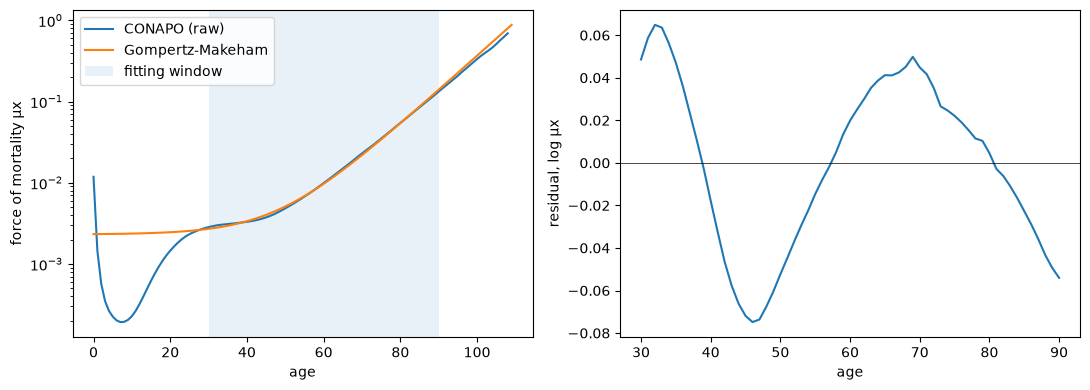

In [5]:
nat = fitted[(fitted.state_code == 0) & (fitted.sex == "total")]
p = params[(params.state_code == 0) & (params.sex == "total")].iloc[0]
ages = nat.age.to_numpy()
mu_raw = gompertz.qx_to_mu(nat.qx.to_numpy())
mu_fit = gompertz.gompertz_makeham(ages, p.A, p.B, p.c)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(ages, mu_raw, label="CONAPO (raw)")
ax[0].semilogy(ages, mu_fit, label="Gompertz-Makeham")
ax[0].axvspan(p.age_min, p.age_max, alpha=0.1, label="fitting window")
ax[0].set_xlabel("age"); ax[0].set_ylabel("force of mortality μx"); ax[0].legend()
w = (ages >= p.age_min) & (ages <= p.age_max)
ax[1].plot(ages[w], np.log(mu_raw[w]) - np.log(mu_fit[w]))
ax[1].axhline(0, color="black", linewidth=0.5)
ax[1].set_xlabel("age"); ax[1].set_ylabel("residual, log μx")
plt.tight_layout()

## 4. Write outputs

`fitted_qx.csv` carries `qx_fitted` (smoothed inside 30–90, raw elsewhere) and `qx_source` so the app can label each value. `version.json` records the raw snapshot checksums and the run date so every served number is traceable.

In [6]:
params.to_csv(PROCESSED / "gompertz_makeham_params.csv", index=False, float_format="%.10g")
fitted[["state_code", "sex", "age", "qx_fitted", "qx_source"]].to_csv(
    PROCESSED / "fitted_qx.csv", index=False, float_format="%.10g"
)
versioning.write_version(
    REFERENCE_YEAR,
    [conapo.DEATHS_FILE, conapo.POPULATION_FILE, conapo.INDICATORS_FILE],
    {
        "gompertz_makeham": {"fit_age_min": gompertz.FIT_AGE_MIN, "fit_age_max": gompertz.FIT_AGE_MAX, "loss": "least squares on log(mu_x)"},
        "life_table": {"radix": 100000, "a0": 0.1, "ax": 0.5, "closure": "open interval at last age with exposure"},
        "produced_by": ["01_build_life_tables.ipynb", "02_fit_gompertz_makeham.ipynb"],
    },
)

{'methodology_version': '1.0.0',
 'data_source': 'CONAPO, Proyecciones de la Población de México y las Entidades Federativas 2020-2070 (pry23)',
 'reference_year': 2023,
 'processed_on': '2026-09-25',
 'raw_files': [{'file': '01_Defunciones_1950_2070.csv',
   'sha256': '9d5c24f09e3739044d301f8886d59bf6336f1908434c37ee29962642d1bfa075'},
  {'file': '00_Pob_Mitad_1950_2070.csv',
   'sha256': '89db6adc7930965fb5b5c01ad3a98765ed90afa6a151c2cfb913acc2b9e0cac6'},
  {'file': '05_Indicadores_demograficos_proyecciones.csv',
   'sha256': 'e0407d1640f38232023cf97656a0cb7be46049b1cb2344198c7e4aaec7cae6cd'}],
 'gompertz_makeham': {'fit_age_min': 30,
  'fit_age_max': 90,
  'loss': 'least squares on log(mu_x)'},
 'life_table': {'radix': 100000,
  'a0': 0.1,
  'ax': 0.5,
  'closure': 'open interval at last age with exposure'},
 'produced_by': ['01_build_life_tables.ipynb',
  '02_fit_gompertz_makeham.ipynb']}